In [1]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [ ]:
from scipy import stats

In [ ]:
from functions import preproc_funcs as funcs

In [ ]:
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [ ]:
# import mpatches
import matplotlib.patches as mpatches


In [ ]:
import regionmask

In [ ]:
def plot_background(ax, draw_labels=False, draw_ipcc_regions=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    if draw_ipcc_regions:
        ar6_reg = regionmask.defined_regions.ar6.all

        # Plot the region boundaries, passing the same 'ax'
        # Use 'line_kws' to customize line properties (color, thickness, etc.)
        ar6_reg.plot_regions(
            ax=ax,
            line_kws=dict(color='black', lw=1.0, alpha=0.4),
            text_kws=dict(fontsize=8, color='k'), # Set to True to add text labels for regions
            add_label=False, # Set to True to add text labels for regions
        )
    return ax




def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, draw_ipcc_regions=False, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax, draw_labels=draw_labels, draw_ipcc_regions=draw_ipcc_regions)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_not_equal(pval[i], 0)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='///', transform = ccrs.PlateCarree(central_longitude=0))
                # pval_plot = xr.where(pval[i] > 0.05, True, False)
                # axlist[i].scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker='.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_not_equal(pval[i], 1)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
                # pval_plot = xr.where(pval[i] <= 0.05, True, False)
                # axlist[i].scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker='.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.01, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return axlist



def plot_single_map(x, y, z, title, label, cmap, levels, add_sign=False, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, draw_ipcc_regions=False, auto_aspect=False):

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)
    plot_background(ax, draw_labels=draw_labels, draw_ipcc_regions=draw_ipcc_regions)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 5
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if add_sign:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='//', transform = ccrs.PlateCarree(central_longitude=0))
            # pval_plot = xr.where(pval > 0.05, True, False)
            # ax.scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker = '.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='..', transform = ccrs.PlateCarree(central_longitude=0))
            # pval_plot = xr.where(pval <= 0.05, True, False)
            # ax.scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker = '.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.01, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])

In [ ]:
import cmocean

### load data

In [ ]:
pr_cp_son = xr.open_dataset('./data/res/indiv_years/son/pr_cp.nc')
pr_ep_son = xr.open_dataset('./data/res/indiv_years/son/pr_ep.nc')
pr_neut_son = xr.open_dataset('./data/res/indiv_years/son/pr_neut.nc')

pr_cp_djf = xr.open_dataset('./data/res/indiv_years/djf/pr_cp.nc')
pr_ep_djf = xr.open_dataset('./data/res/indiv_years/djf/pr_ep.nc')
pr_neut_djf = xr.open_dataset('./data/res/indiv_years/djf/pr_neut.nc')

pr_cp_mam = xr.open_dataset('./data/res/indiv_years/mam/pr_cp.nc')
pr_ep_mam = xr.open_dataset('./data/res/indiv_years/mam/pr_ep.nc')
pr_neut_mam = xr.open_dataset('./data/res/indiv_years/mam/pr_neut.nc')

In [ ]:
bstrap_pr_cp_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_cp_agreement_mask_son.nc')
bstrap_pr_ep_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_ep_agreement_mask_son.nc')

bstrap_pr_cp_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_cp_agreement_mask_djf.nc')
bstrap_pr_ep_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_ep_agreement_mask_djf.nc')

bstrap_pr_cp_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_cp_agreement_mask_mam.nc')
bstrap_pr_ep_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_ep_agreement_mask_mam.nc')

In [ ]:
plot_list = [
    # son
    pr_cp_son.prate.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    pr_ep_son.prate.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # (pr_cp_son.prate.mean('time') - pr_ep_son.prate.mean('time')).sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # djf
    pr_cp_djf.prate.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    pr_ep_djf.prate.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # (pr_cp_djf.prate.mean('time') - pr_ep_djf.prate.mean('time')).sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # # mam
    pr_cp_mam.prate.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    pr_ep_mam.prate.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # (pr_cp_mam.prate.mean('time') - pr_ep_mam.prate.mean('time')).sel(lat = slice(-55, 55), lon = slice(60, 330)),
]

In [ ]:
pval_list = [
    # son
    bstrap_pr_cp_son.prate.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    bstrap_pr_ep_son.prate.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # bstrap_pr_cp_son.prate* bstrap_pr_ep_son.prate,
    # np.empty_like(bstrap_pr_cp_son.prate),
    # djf
    bstrap_pr_cp_djf.prate.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    bstrap_pr_ep_djf.prate.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # np.empty_like(bstrap_pr_cp_djf.prate),
    # # mam
    bstrap_pr_cp_mam.prate.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    bstrap_pr_ep_mam.prate.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # # bstrap_pr_cp_mam.prate * bstrap_pr_ep_mam.prate,
    # np.empty_like(bstrap_pr_cp_mam.prate),
]

In [ ]:
import cmocean

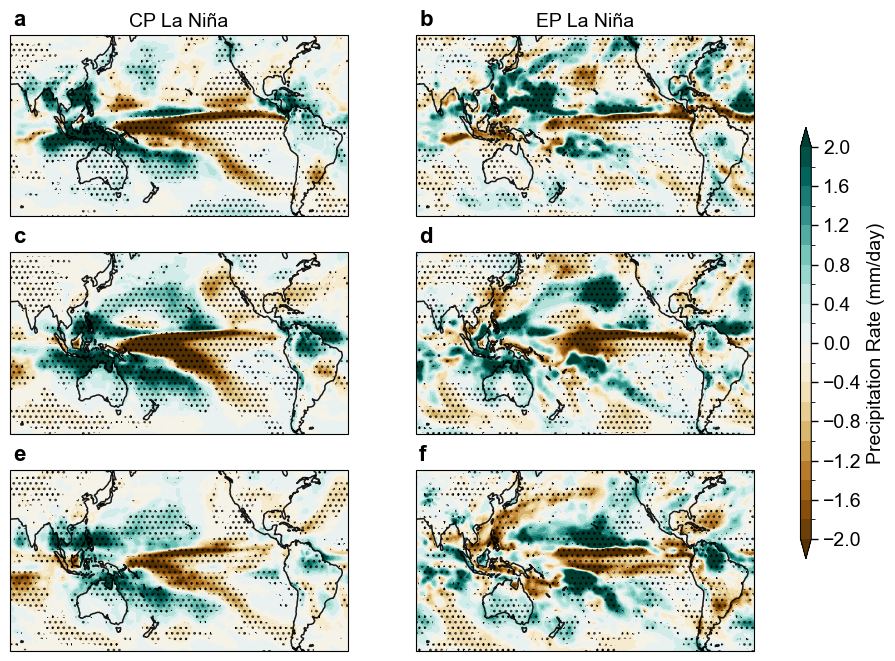

In [15]:
xx, yy = np.meshgrid(pr_cp_son.sel(lat = slice(-55, 55), lon = slice(60, 330)).lon, pr_cp_son.sel(lat = slice(-55, 55), lon = slice(60, 330)).lat)

axlist = plot_maps(xx, yy, plot_list, 
          titles=['CP La Niña','EP La Niña'#,'CP - EP La Niña',
                  '','','',
                  '','',''],
          labels=['a','b','c','d','e','f'],#,'g','h','i'],
          cmap='BrBG',
          levels=np.linspace(-2.0, 2.0, 21),
          pval=pval_list,
          hatch_type='sig',
          nrows=3,
          ncols=2,
          figsize=(12,8),
          cbar_kwargs=dict(orientation='vertical', label='Precipitation Rate (mm/day)', aspect=40, shrink=0.7, pad=0.05),
          draw_labels=False,
          proj=ccrs.PlateCarree(central_longitude=160),
          land_mask_list=[],
          draw_ipcc_regions=False,
          auto_aspect=True,
          )
    

# change each subplot extent to focus on the region of interest defined above
for ax in axlist:
    ax.set_extent([60, 330, -55, 55], crs=ccrs.PlateCarree())

# add DJF, MAM and SON labels to the left of the rows
# plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, hspace=0.3, wspace=0.2)
# plt.figtext(0.10, 0.75, 'SON', fontsize=16, fontweight='bold', rotation='vertical')
# plt.figtext(0.10, 0.48, 'DJF', fontsize=16, fontweight='bold', rotation='vertical')
# plt.figtext(0.10, 0.2, 'MAM', fontsize=16, fontweight='bold', rotation='vertical')